In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import matplotlib.ticker as mtick

In [25]:
df = pd.read_csv("emissions.csv", sep =",")
n_cases = 4
n_materials = 6

df

,Category,Initial_PA.Nylon,Initial_PA_return,Targeted_PA.Nylon,Targeted_PA_return,Incentive_PA.Nylon,Incentive_PA_return,Normal_PA.Nylon,Normal_PA_return,Initial_PES,...,Normal_CO_return,Initial_LI_Flax,Initial_LI_return,Targeted_LI_Flax,Targeted_LI_return,Incentive_LI_Flax,Incentive_LI_return,Normal_LI_Flax,Normal_LI_return,Unit
0,"Climate change, incl biogenic carbon",9597.959,7085.040,9445.184,7015.472,9031.978,6731.090,9521.986,7036.941,145511.865,...,602.020,74.784,53.224,74.784,53.224,73.406,52.536,74.094,52.536,kg CO2-Eq.
1,Freshwater aquatic ecotoxicity,35.533,26.230,34.968,25.973,33.438,24.920,35.252,26.052,4724.477,...,59.224,3.974,2.828,3.974,2.828,3.901,2.792,3.937,2.792,kg 1.4 DCB eq.
2,Marine aquatic ecotoxicity,49.000,36.171,48.220,35.815,46.110,34.364,48.612,35.925,6315.233,...,48.337,4.588,3.265,4.588,3.265,4.503,3.223,4.546,3.223,kg 1.4 DCB eq.
3,Terrestrial ecotoxicity,2257.508,1666.452,2221.574,1650.089,2124.385,1583.200,2239.639,1655.138,535417.090,...,2052.612,317.894,226.248,317.894,226.248,312.039,223.323,314.964,223.323,kg 1.4 DCB eq.
4,Freshwater Eutrophication,0.500,0.369,0.492,0.366,0.471,0.351,0.496,0.367,37.767,...,0.558,0.025,0.018,0.025,0.018,0.024,0.018,0.025,0.018,kg P eq.
5,Marine Eutrophication,2.778,2.050,2.734,2.030,2.614,1.948,2.756,2.037,12.895,...,5.449,0.252,0.179,0.252,0.179,0.247,0.177,0.249,0.177,kg N eq.
6,Terrestrial Acidification,27.144,20.037,26.712,19.840,25.543,19.036,26.929,19.901,403.199,...,7.421,1.080,0.769,1.080,0.769,1.060,0.759,1.070,0.759,kg SO2 eq.
7,Photochemical Ozone Formation. Ecosystems,17.234,12.722,16.960,12.597,16.218,12.087,17.098,12.636,383.569,...,2.402,0.356,0.253,0.356,0.253,0.350,0.250,0.353,0.250,kg NOx eq.
8,lonizing Radiation,1.743,1.287,1.715,1.274,1.640,1.222,1.729,1.278,7296.447,...,8.412,1.519,1.081,1.519,1.081,1.491,1.067,1.505,1.067,kBq Co-60 eq.
9,"Human toxicity, cancer",181.077,133.668,178.195,132.355,170.399,126.990,179.644,132.761,7198.569,...,25.960,3.746,2.666,3.746,2.666,3.677,2.631,3.711,2.631,kg 1.4-DB eq.


In [26]:
df = df[df.Category.isin(["Climate change, incl biogenic carbon",
"Freshwater aquatic ecotoxicity",
"Terrestrial ecotoxicity",
"Human toxicity, cancer",
"Human toxicity, non-cancer",
"Fossil depletion"])].reset_index()
df.Category = df.Category.str.replace(',', '\n')
df.Category = df.Category + " in " + df.Unit

In [27]:
materials = [string.rsplit("_", 1)[1] for string in df.columns[list(range(2, len(df.columns)-1, 8))]]
cases = [string.rsplit("_", 1)[0] for string in df.columns[list(range(2, 9, 2))]]
df

,index,Category,Initial_PA.Nylon,Initial_PA_return,Targeted_PA.Nylon,Targeted_PA_return,Incentive_PA.Nylon,Incentive_PA_return,Normal_PA.Nylon,Normal_PA_return,...,Normal_CO_return,Initial_LI_Flax,Initial_LI_return,Targeted_LI_Flax,Targeted_LI_return,Incentive_LI_Flax,Incentive_LI_return,Normal_LI_Flax,Normal_LI_return,Unit
0,0,Climate change\n incl biogenic carbon in kg CO...,9597.959,7085.040,9445.184,7015.472,9031.978,6731.090,9521.986,7036.941,...,602.020,74.784,53.224,74.784,53.224,73.406,52.536,74.094,52.536,kg CO2-Eq.
1,1,Freshwater aquatic ecotoxicity in kg 1.4 DCB eq.,35.533,26.230,34.968,25.973,33.438,24.920,35.252,26.052,...,59.224,3.974,2.828,3.974,2.828,3.901,2.792,3.937,2.792,kg 1.4 DCB eq.
2,3,Terrestrial ecotoxicity in kg 1.4 DCB eq.,2257.508,1666.452,2221.574,1650.089,2124.385,1583.200,2239.639,1655.138,...,2052.612,317.894,226.248,317.894,226.248,312.039,223.323,314.964,223.323,kg 1.4 DCB eq.
3,9,Human toxicity\n cancer in kg 1.4-DB eq.,181.077,133.668,178.195,132.355,170.399,126.990,179.644,132.761,...,25.960,3.746,2.666,3.746,2.666,3.677,2.631,3.711,2.631,kg 1.4-DB eq.
4,10,Human toxicity\n non-cancer in kg 1.4-DB eq.,596.717,440.486,587.219,436.161,561.530,418.480,591.994,437.496,...,1056.275,-108.060,-76.907,-108.060,-76.907,-106.070,-75.913,-107.064,-75.913,kg 1.4-DB eq.
5,15,Fossil depletion in kg oil eq.,2990.261,2207.357,2942.664,2185.683,2813.929,2097.083,2966.592,2192.372,...,98.232,13.575,9.661,13.575,9.661,13.325,9.536,13.449,9.536,kg oil eq.


In [28]:
# Summed up totals over materials per case
total_sums = df.Category

# Summed up returns materials per case
return_sums = df.Category

totals = df.Category

cat1 = pd.DataFrame(columns= ["Scenario"] + materials)
cat1['Scenario'] = cases

for i in range(2, 9, 2):
    total_sums = pd.concat([total_sums, 
                            df.iloc[:, [index for index in range(i, len(df.columns)-1, 8)]].sum(axis=1)], 
                           axis = 1)
    totals = pd.concat([totals, 
                            df.iloc[:, [index for index in range(i, len(df.columns)-1, 8)]]], 
                           axis = 1)
    
    # cat1.iloc[int(i/2-1), 1:] = totals.iloc[0,int(((i/2-1)*len(materials)+1)):int(((i/2-1)*len(materials))+len(materials)+1)]
    
    return_sums = pd.concat([return_sums, 
                            df.iloc[:, [index for index in range(i+1, len(df.columns)-1, 8)]].sum(axis=1)], 
                           axis = 1)

total_sums.columns.values[1:] = cases
return_sums.columns.values[1:] = cases

materials_sum = df.Category

# Get Summed up Materials
for i in range(2, len(df.columns)-1, 8):
    materials_sum = pd.concat([materials_sum,
               df.iloc[:, [index for index in range(i, i+8, 2)]].sum(axis=1)], axis = 1)

materials_sum.columns.values[1:] = materials

materials_sum.iloc[:, 1:] = materials_sum.iloc[:, 1:].div(materials_sum.iloc[:, 1:].sum(axis=1), axis='index')*100

In [29]:
font = {'family' : 'sans-serif',
'weight' : 'normal',
'size'   : 15}
plt.rc('font', **font)
 
def apply_plot_layout(ax,Grid=True):
 
    #_______LABEL
    #ax.set_ylabel("defect found")
    #ax.set_xlabel(r"time [s]")
    ax.tick_params(direction='in')
    #ax.set_yticks=([0,1])
 
    #_______LEGEND
    #ax.legend(loc="best",fontsize=8, framealpha=0.5,ncol=1,fancybox=True)
    #ax.legend(loc='lower left',fontsize=10, framealpha=0.9,ncol=1)
 
    #_________GRID
    #plt.grid(linestyle=(0, (1, 10)), linewidth=1, alpha=0.5)
    ax.grid(linestyle=':',linewidth=1, alpha=0.5)
    if Grid==False: 
        ax.grid(False)
 
 
    #______SET ASPECT
    #axisratio=(1+np.sqrt(5))/2
    #axisratio=1.5
    #y_min, y_max = ax.get_ylim()
    #x_min, x_max = ax.get_xlim()
    #ax.set_aspect((x_max-x_min)/(y_max-y_min)/axisratio, adjustable='box')
    
    #_______AXES LINEWIDTH
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.3)
    #plt.tight_layout(pad=0.5)
    return

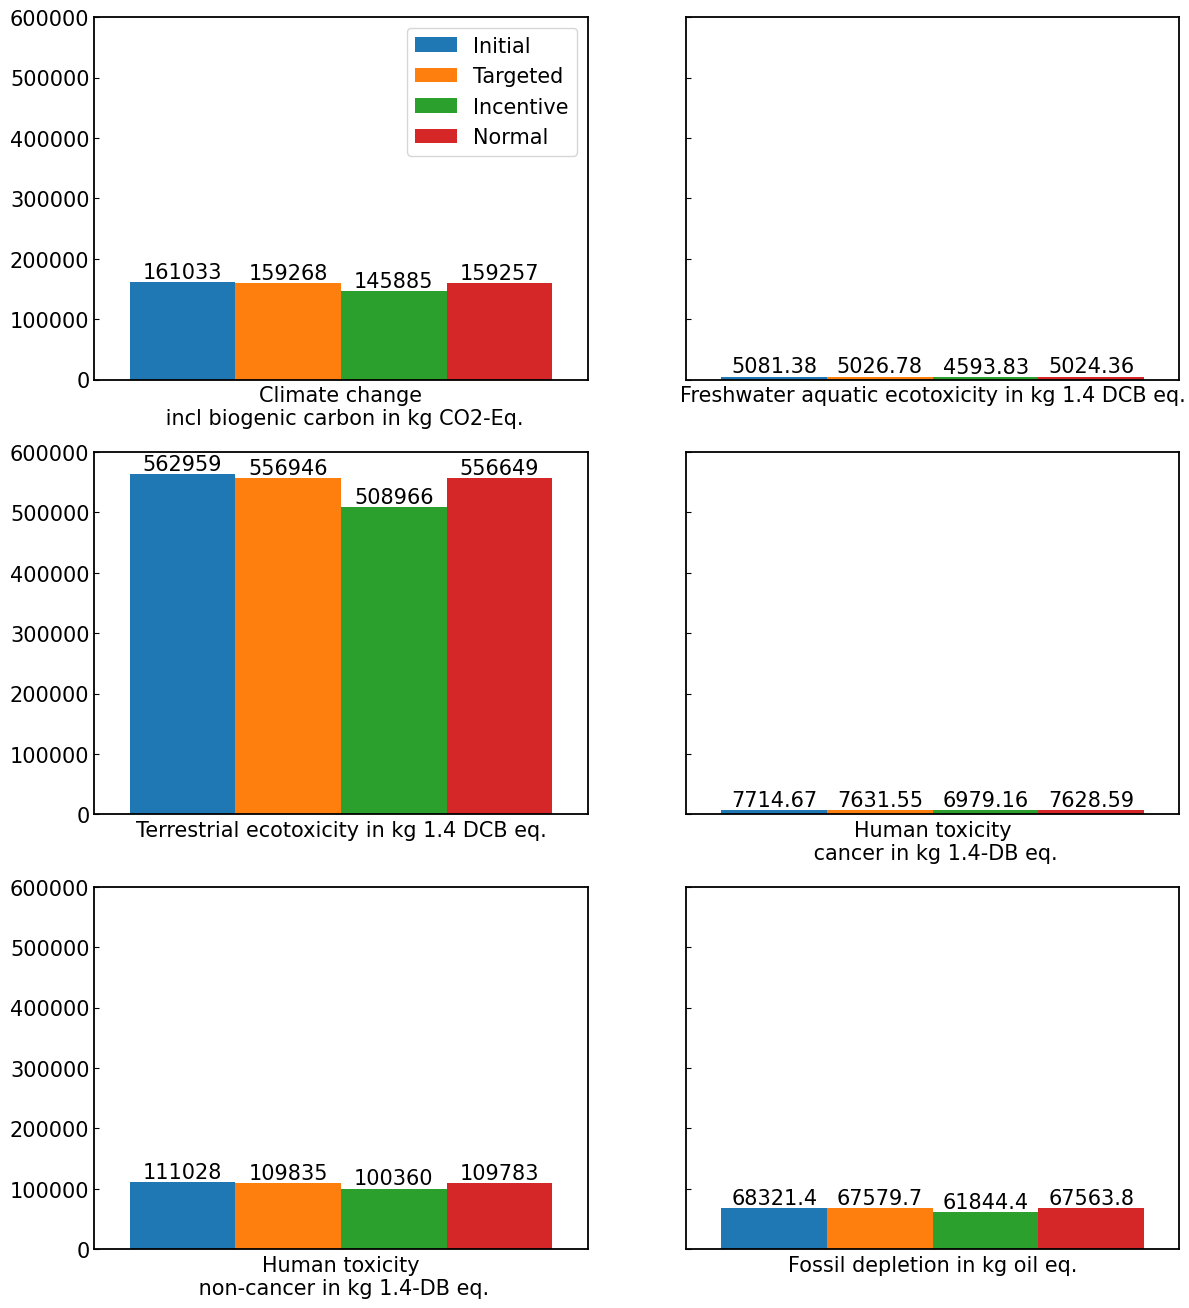

In [30]:
# total_sums.plot.bar(logy = True, x='Category', stacked = False, rot=15, figsize=(15,5))
# total_sums.sort_values(by=['col1'])

nrows = 3
ncols = 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharey=True, figsize=(14, 16))
i = 0
legend = True
for row in range(nrows):
    for col in range(ncols):
        if i == 1:
            legend = False
        ax = axes[row, col]
        apply_plot_layout(ax)
        total_sums.iloc[i, :].to_frame().T.plot.bar(ax=ax, 
                                                    xlabel=total_sums.iloc[i, 0], 
                                                    xticks= [], 
                                                    rot = 0, 
                                                    stacked = False, 
                                                    legend = legend,
                                                    ylim = (0, 600000),
                                                    width = 3)
        for container in ax.containers:
            ax.bar_label(container)
        i+=1

The bar chart illustrates the impact of four different clothing sales scenarios (Initial, Targeted, Incentive, and Normal) on six environmental metrics: Climate Change, Freshwater Aquatic Ecotoxicity, Terrestrial Ecotoxicity, Human Toxicity (Cancer), Human Toxicity (Non-Cancer), and Fossil Depletion. It should be noted that although the scale is the same, the units are not the same for all metrics. Care should therefore be taken when comparing values across metrics. 
The chart highlights the significant impact that different sales strategies can have on the environment. The "Incentive" scenario consistently outperforms the others across all six metrics, indicating that it is the most sustainable option. It should also be noted that the relative proportions of the scenarios are very similar in the various metrics.

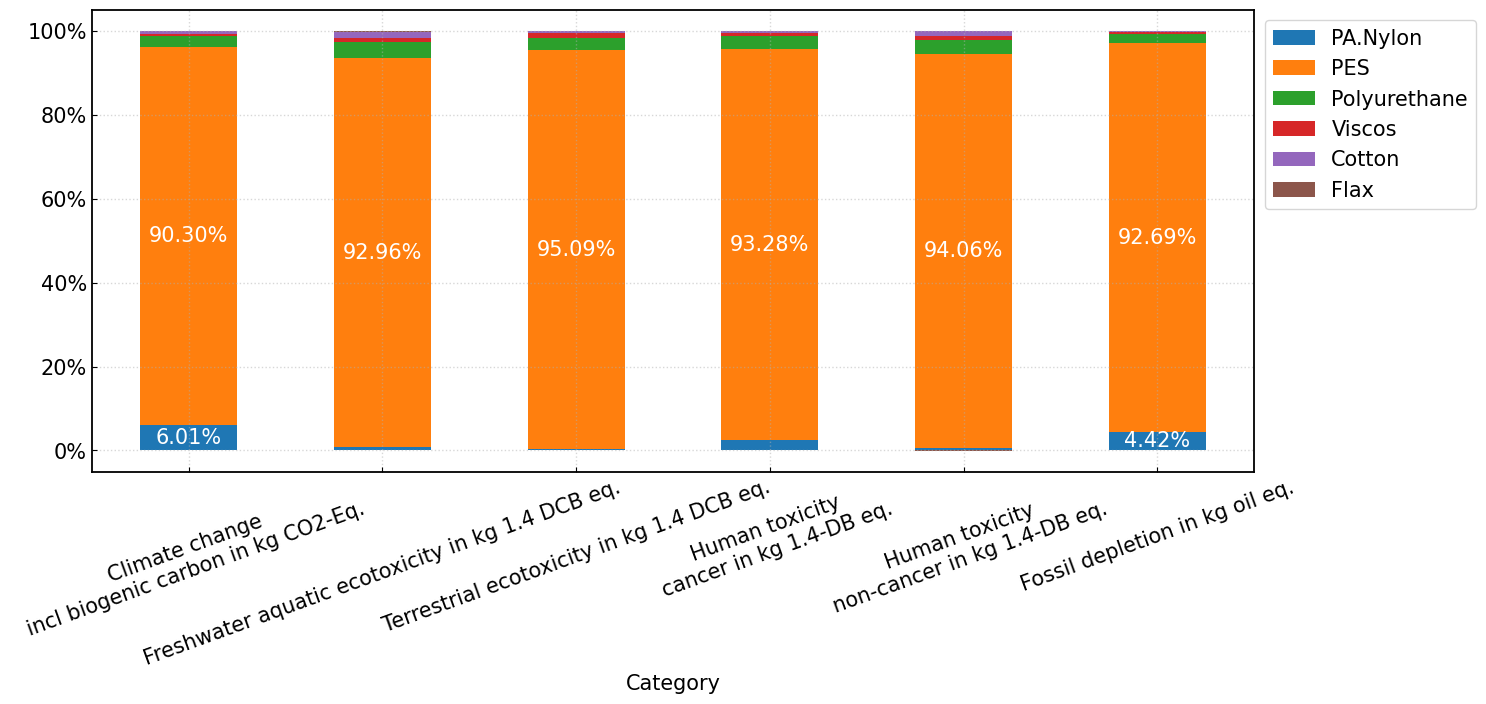

In [31]:
ax = materials_sum.plot.bar(stacked = True, x = "Category", rot=20, figsize=(15,6))
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(bbox_to_anchor=(1.0, 1.0))
apply_plot_layout(ax)

labels = [f'{i/100:.2%}' if i >= 4 else "" for i in materials_sum.iloc[:, 1:].to_numpy().flatten(order='F')]

for i, patch in enumerate(ax.patches):
    x, y = patch.get_xy()
    x += patch.get_width() / 2
    y += patch.get_height() / 2
    ax.annotate(labels[i], (x, y), ha='center', va='center', c='white')

This chart illustrates the relative impact of different fabric materials on six environmental metrics across four scenarios: Initial, Targeted, Incentive, and Normal. It can be observed that the material composition of the clothes significantly influences the environmental footprint. For instance, the use of PA.Nylon consistently contributes to a higher impact across all metrics compared to other fabrics. In contrast, PES and Viscos generally exhibit lower environmental impacts. Cotton and Flax also demonstrate relatively low impacts, particularly in terms of Freshwater Aquatic Ecotoxicity and Terrestrial Ecotoxicity. The "Incentive" scenario consistently demonstrates the lowest overall environmental impact, likely due to a combination of factors such as material selection, production processes, and consumer behavior. This analysis underscores the importance of considering fabric composition in efforts to promote sustainable clothing consumption.